# MSES Example

First, set the environment variables (start + edit the system environment variables) for the MSES folder (all .exe hosted here) and the osmapDP.dat file.

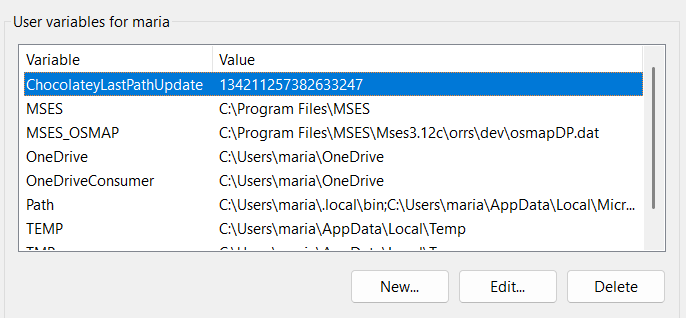

Restart your editor, and run the following:

## Import Modules

In [1]:
import os
import tempfile
from pathlib import PureWindowsPath

from pymead.analysis.calc_aero_data import (calculate_aero_data, MSETSettings, MSESSettings, MPLOTSettings,
                                            AirfoilMSETMeshingParameters)
from pymead.core.geometry_collection import GeometryCollection


## Main function definition

In [2]:
def main():
    # Create a geometry collection
    geo_col = GeometryCollection()

    # Download the airfoil and create an Airfoil object from it
    polyline = geo_col.add_polyline(source="naca23012-il")
    airfoil = polyline.add_polyline_airfoil()

    # Create an MEA object from the airfoil (required for MSES analysis)
    mea = geo_col.add_mea([airfoil])

    # Configure the MSET settings
    mset_settings = MSETSettings(
        multi_airfoil_grid={"Airfoil-1": AirfoilMSETMeshingParameters()},
        airfoil_side_points=180
    )

    # Friendlier MSES settings — alpha mode, higher Re, modest AoA
    mses_settings = MSESSettings(
        xtrs={"Airfoil-1": [1.0, 1.0]},  # free transition (now works since osmap is loaded)
        Ma=0.2,
        Re=1.0e6,
        alfa=2.0,           # specify alpha directly
        alfa_Cl_mode=0,     # 0 = alpha mode, 1 = Cl mode
        timeout=60.0
    )

    mplot_settings = MPLOTSettings(Tecplot=True)

    print(f"Running MSES...")
    aero_data, logs = calculate_aero_data(
        conn=None,
        airfoil_coord_dir=tempfile.gettempdir(),
        airfoil_name="naca23012",
        mea=mea,
        tool="MSES",
        mset_settings=mset_settings,
        mses_settings=mses_settings,
        mplot_settings=mplot_settings,
        export_Cp=True,
        save_aero_data=True,
    )

    analysis_dir = PureWindowsPath(os.path.normpath(os.path.abspath(os.path.dirname(logs['mset'])))).as_posix()
    print(f"Output directory: file:///{analysis_dir}")

    if not aero_data["converged"]:
        raise ValueError("MSES did not converge")
    if aero_data["errored_out"]:
        raise ValueError("MSES errored out")
    if aero_data["timed_out"]:
        raise ValueError("MSES timed out")
    print(f"Cl: {aero_data['Cl']:.2f} | Cd: {aero_data['Cd'] * 1e4:.2f} counts | Cm: {aero_data['Cm']:.3f}")


Note: the original settings from the example in the pymead github didn't work for me. I had to increase the Re from 3e5 to 1e6.

## Run

In [3]:
if __name__ == "__main__":
    main()

Running MSES...
Output directory: file:///C:/Users/maria/AppData/Local/Temp/naca23012
Cl: 0.33 | Cd: 67.05 counts | Cm: -0.002
